In [29]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import spearmanr

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [30]:
# Configuration and paths
mac = 20

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [31]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(['ENSG00000131471', 'ENSG00000084674'])),

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .unique()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


consequence_splice_donor_variant,id,consequence_stop_gained,encode_tf,gpn_score,absplice2_max,relative_cds_position,ted_domain,five_prime_utr_variant_consequence_uaug_gained,pangolin_score,five_prime_utr_variant_consequence_uaug_lost,consequence_splice_acceptor_variant,promoterai,abexp_min,mobi_curated_disorder_priority,encode_dels,esmscoremissense,cadd_raw,abexp_abs_max,consequence_stop_lost,low_complexity_domain,delta_score,consequence_frameshift_variant,loftee_lc,five_prime_utr_variant_consequence_ustop_lost,loftee_hc,verphylop,consequence_synonymous_variant,am_pathogenicity,encode_pels,mobi_lip_full,five_prime_utr_variant_consequence_ustop_gained,region,aparent2,consequence_start_lost,consequence_missense_variant,encode_pls
i8,str,i8,bool,f32,f32,f32,bool,u8,f32,u8,i8,f32,f32,bool,bool,f32,f32,f32,i8,bool,f32,i8,i8,u8,i8,f32,i8,f32,bool,bool,u8,str,f32,i8,i8,bool
0,"""chr2:21043471:G:C""",0,false,-1.3,0.000143,0.0,false,0,0.01,0,0,-0.0352,-0.021971,false,false,0.0,0.570169,0.021971,0,false,0.01,0,0,0,0,-0.016,0,0.0,true,false,0,"""ENSG00000084674""",0.0,0,0,false
0,"""chr2:21005183:A:T""",0,false,-7.01,0.000033,0.85,false,0,0.0,0,0,0.0,-0.015699,false,false,-2.641,2.484871,0.015699,0,false,0.0,0,0,0,0,0.359,0,0.2268,false,false,0,"""ENSG00000084674""",0.0,0,1,false
0,"""chr17:42856378:C:G""",0,false,-9.88,0.000504,0.92,true,0,0.0,0,0,0.0,-0.083133,false,true,-13.743,4.832917,0.083133,0,false,0.0,0,0,0,0,7.32,0,0.7409,false,false,0,"""ENSG00000131471""",0.0,0,1,false
0,"""chr2:21043348:C:A""",0,false,-1.47,0.00035,0.0,false,0,0.8,0,0,0.0,-0.06356,false,false,0.0,0.415912,0.06356,0,false,0.95,0,0,0,0,0.015,0,0.0,false,false,0,"""ENSG00000084674""",0.0,0,0,false
0,"""chr2:21000563:G:C""",0,false,-1.24,0.0,0.0,false,0,0.0,0,0,0.0,-0.019552,false,false,0.0,0.045969,0.019552,0,false,0.0,0,0,0,0,-0.246,0,0.0,false,false,0,"""ENSG00000084674""",0.0,0,0,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,"""chr2:21007933:C:A""",0,false,-5.07,0.000034,0.65,false,0,0.01,0,0,0.0,-0.022022,false,false,-6.556,2.137541,0.022022,0,false,0.0,0,0,0,0,0.041,0,0.1499,false,false,0,"""ENSG00000084674""",0.0,0,1,false
0,"""chr2:21038139:A:G""",0,false,-1.25,0.001405,0.0,false,0,0.03,0,0,0.0,-0.03079,false,true,0.0,-0.382058,0.03079,0,false,0.06,0,0,0,0,-0.271,0,0.0,false,false,0,"""ENSG00000084674""",0.0,0,0,false
0,"""chr17:42862441:C:T""",0,false,0.07,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,false,0.0,0.097402,0.0,0,false,0.0,0,0,0,0,0.184,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false


# Olink scatter plot

In [32]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

olink_appv

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr17:42847512:G:A""","""ENSG00000131471_olink""",0.647733,1
"""chr17:42854956:C:T""","""ENSG00000131471_olink""",0.14298,1
"""chr17:42848897:C:G""","""ENSG00000131471_olink""",-0.639064,2
"""chr17:42848090:T:TTTA""","""ENSG00000131471_olink""",-0.595697,2
"""chr17:42859525:C:T""","""ENSG00000131471_olink""",0.692828,1
…,…,…,…
"""chr17:42852113:C:T""","""ENSG00000131471_olink""",-0.652947,1
"""chr17:42846621:C:T""","""ENSG00000131471_olink""",1.215292,1
"""chr17:42856030:T:TGTC""","""ENSG00000131471_olink""",-0.740016,1


In [33]:
olink_plot_df = (
    anno
    .join(
        olink_appv, on='id', how='inner'
    )
)

olink_plot_df

consequence_splice_donor_variant,id,consequence_stop_gained,encode_tf,gpn_score,absplice2_max,relative_cds_position,ted_domain,five_prime_utr_variant_consequence_uaug_gained,pangolin_score,five_prime_utr_variant_consequence_uaug_lost,consequence_splice_acceptor_variant,promoterai,abexp_min,mobi_curated_disorder_priority,encode_dels,esmscoremissense,cadd_raw,abexp_abs_max,consequence_stop_lost,low_complexity_domain,delta_score,consequence_frameshift_variant,loftee_lc,five_prime_utr_variant_consequence_ustop_lost,loftee_hc,verphylop,consequence_synonymous_variant,am_pathogenicity,encode_pels,mobi_lip_full,five_prime_utr_variant_consequence_ustop_gained,region,aparent2,consequence_start_lost,consequence_missense_variant,encode_pls,phenotype,mean_pheno_value,n_individuals
i8,str,i8,bool,f32,f32,f32,bool,u8,f32,u8,i8,f32,f32,bool,bool,f32,f32,f32,i8,bool,f32,i8,i8,u8,i8,f32,i8,f32,bool,bool,u8,str,f32,i8,i8,bool,str,f32,i32
0,"""chr17:42856378:C:G""",0,false,-9.88,0.000504,0.92,true,0,0.0,0,0,0.0,-0.083133,false,true,-13.743,4.832917,0.083133,0,false,0.0,0,0,0,0,7.32,0,0.7409,false,false,0,"""ENSG00000131471""",0.0,0,1,false,"""ENSG00000131471_olink""",-4.037116,1
0,"""chr17:42858084:A:T""",0,false,-3.39,0.000033,0.0,false,0,0.0,0,0,0.0,-0.005792,false,false,0.0,0.327057,0.005792,0,false,0.0,0,0,0,0,0.812,0,0.0,false,false,0,"""ENSG00000131471""",0.13513,0,0,false,"""ENSG00000131471_olink""",-0.519862,1
0,"""chr17:42848655:A:G""",0,false,-0.44,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,true,0.0,-0.016346,0.002469,0,false,0.0,0,0,0,0,-0.254,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false,"""ENSG00000131471_olink""",0.634121,1
0,"""chr17:42859903:G:A""",0,false,1.13,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,false,0.0,0.252647,0.0,0,false,0.0,0,0,0,0,-0.577,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false,"""ENSG00000131471_olink""",-0.583541,1
0,"""chr17:42848065:C:CTTTTTTTTTTTT…",0,false,-1.41,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,false,0.0,-0.245866,0.0,0,false,0.0,0,0,0,0,0.129,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false,"""ENSG00000131471_olink""",-1.44075,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,"""chr17:42860948:CA:C""",0,false,-1.41,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,false,0.0,-0.629499,0.0,0,false,0.0,0,0,0,0,0.129,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false,"""ENSG00000131471_olink""",-0.311401,1
0,"""chr17:42849114:CGTG:C""",0,false,-1.41,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,true,0.0,1.488877,0.0,0,false,0.0,0,0,0,0,0.129,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false,"""ENSG00000131471_olink""",-0.916073,1
0,"""chr17:42860477:TTTTC:T""",0,false,-1.41,0.0,0.0,false,0,0.0,0,0,0.0,0.0,false,false,0.0,0.28051,0.0,0,false,0.0,0,0,0,0,0.129,0,0.0,false,false,0,"""ENSG00000131471""",0.0,0,0,false,"""ENSG00000131471_olink""",0.915136,1


In [34]:
# Select annotation to plot
selected_annotation = 'am_pathogenicity'

# Look up color and label from config
_anno_row = anno_config_df.filter(pl.col('annotation') == selected_annotation)
anno_color = _anno_row['color'][0]
anno_label = _anno_row['label'][0]

print(f"Annotation: {selected_annotation} → {anno_label} (color: {anno_color})")

Annotation: am_pathogenicity → AlphaMissense (color: #feb72d)


Spearman ρ = -0.308 (p = 1.23e-24)


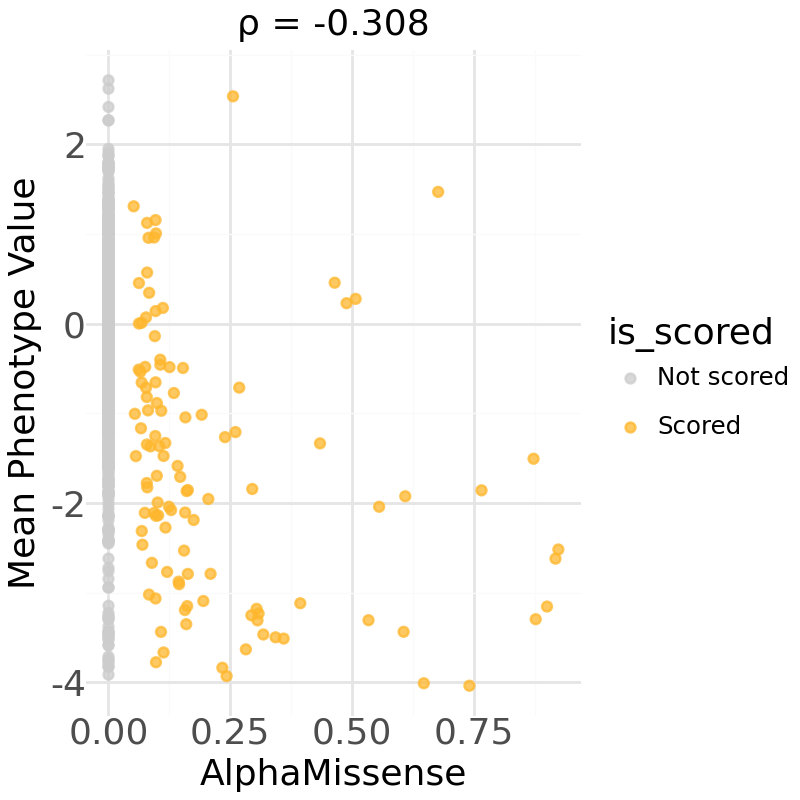

In [46]:
scatter_df = (
    olink_plot_df
    .select(['id', selected_annotation, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        is_scored = pl.when(pl.col(selected_annotation) != 0)
            .then(pl.lit('Scored'))
            .otherwise(pl.lit('Not scored'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    scatter_df[selected_annotation].to_numpy(),
    scatter_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(scatter_df, aes(y='mean_pheno_value', x=selected_annotation))
    + geom_point(aes(color='is_scored'), alpha=0.75, size=1.5)
    + scale_color_manual(
        values={'Scored': anno_color, 'Not scored': '#CCCCCC'},
    )
    + labs(
        x=anno_label,
        y='Mean Phenotype Value',
        title=f'ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(4, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
        legend_position=None
    )
)

Spearman ρ = -0.224 (p = 1.85e-13)


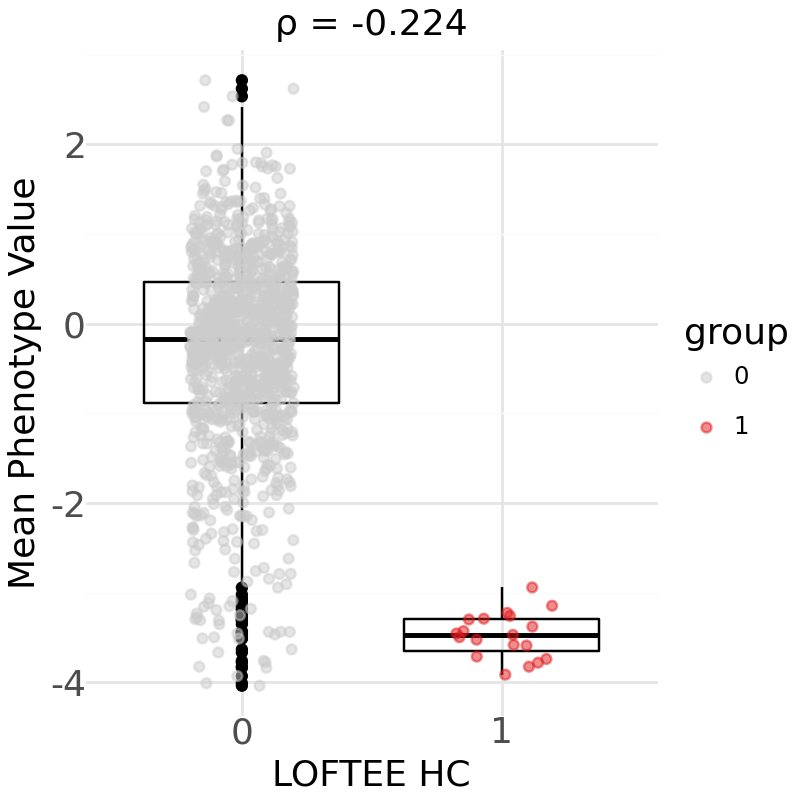

In [45]:
# LOFTEE HC box plot
loftee_anno = 'loftee_hc'
_loftee_row = anno_config_df.filter(pl.col('annotation') == loftee_anno)
loftee_color = _loftee_row['color'][0]
loftee_label = _loftee_row['label'][0]

box_df = (
    olink_plot_df
    .select(['id', loftee_anno, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        group = pl.when(pl.col(loftee_anno) == 1).then(pl.lit('1')).otherwise(pl.lit('0'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    box_df[loftee_anno].to_numpy(),
    box_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(box_df, aes(x='group', y='mean_pheno_value'))
    + geom_boxplot(fill='none', color='black', alpha=0.5)
    + geom_jitter(aes(color='group'), width=0.2, alpha=0.5, size=1.5)
    + scale_color_manual(values={'0': '#CCCCCC', '1': loftee_color})
    + labs(
        x=loftee_label,
        y='Mean Phenotype Value',
        title=f'ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(4, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Pheno scatter plot

In [20]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

pheno_appv

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:21014794:C:T""","""cholesterol_int""",-0.314186,7
"""chr2:21024629:A:C""","""vitamin_d_int""",-0.066045,5
"""chr2:21024629:A:C""","""cholesterol_int""",0.367438,5
"""chr2:21024629:A:C""","""creatinine_int""",-0.762991,5
"""chr2:21019974:GGGTGCAA:G""","""alanine_aminotransferase_int""",-1.304088,7
…,…,…,…
"""chr2:21045674:C:T""","""cholesterol_int""",-0.296104,2
"""chr2:21010186:C:T""","""ldl_direct_int""",-1.135112,3
"""chr2:21045674:C:T""","""standing_height_int""",0.835483,2
